In [1]:
import pandas as pd
import itertools
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# DATA

In [2]:
df_out = pd.read_csv("01_garden_compare_separate.tsv", sep="\t", header=0)
df_out.head()

marker_labels = pd.DataFrame({"marker":["100", "100LF", "1000","10000","1000LF", "all","lfmm","RDA","RDAcorrected"],
                             "Marker":["0.1K", "0.1K-lf", "1K","1K-lf","10K", "~29K","LFMM","RDA","RDA-struct"]})
df = pd.merge(df_out, marker_labels, on = "marker", how = "left")
df.head()

df = df[df["Marker"].isin(["0.1K", "0.1K-lf", "1K","1K-lf","~29K","LFMM","RDA","RDA-struct"])].reset_index(drop=True)
df[df["Marker"].isna()]

,sample,SITE_ID,offset,marker,trait,Trait_name,POP_SITE,POP_ID,SET,mean,sd,n,group,Marker


# Get paiwise correlations

In [3]:
df_sub = df[(df["SITE_ID"] == "ML") & (df["trait"] == "Height") & (df["SET"] == "TEST")].reset_index(drop=True)
df_sub.head()

,sample,SITE_ID,offset,marker,trait,Trait_name,POP_SITE,POP_ID,SET,mean,sd,n,group,Marker
0,1329_ML,ML,0.034574,100,Height,Height,1329_ML,1329,TEST,1435.746514,165.025251,3.0,East,0.1K
1,1528_ML,ML,0.015063,100,Height,Height,1528_ML,1528,TEST,1424.030354,75.498344,3.0,East,0.1K
2,1530_ML,ML,0.044334,100,Height,Height,1530_ML,1530,TEST,976.829721,155.349069,3.0,East,0.1K
3,1531_ML,ML,0.028798,100,Height,Height,1531_ML,1531,TEST,1186.591020,130.000000,3.0,East,0.1K
4,1534_ML,ML,0.010968,100,Height,Height,1534_ML,1534,TEST,1367.178745,110.151411,3.0,East,0.1K


In [4]:
# Get all unique factors and their pairwise combinations

def get_pearsons_corr(dataset):
    factors = dataset["Marker"].unique()
    pairs = list(itertools.combinations(factors, 2))
    pairs
    
    results = []
    
    for f1, f2 in pairs:
        v1 = dataset.loc[dataset["Marker"] == f1, "offset"].values
        v2 = dataset.loc[dataset["Marker"] == f2, "offset"].values
    
        # Only compare if both have the same number of observations
        n = min(len(v1), len(v2))
        rho, pval = pearsonr(v1[:n], v2[:n])
        rho, pval = pearsonr(v1, v2)
        results.append({"marker1": f1, "marker2": f2, "r": rho, "p": pval, "n" : n})
    
    pairwise_corr = pd.DataFrame(results)
    return(pairwise_corr)

In [5]:
get_pearsons_corr(df_sub).head()

,marker1,marker2,r,p,n
0,0.1K,0.1K-lf,0.852054,3.105291e-12,40
1,0.1K,1K,0.967733,2.369100e-24,40
2,0.1K,1K-lf,0.981232,8.984678e-29,40
3,0.1K,~29K,0.981245,8.876179e-29,40
4,0.1K,LFMM,0.866878,4.782305e-13,40


# Loop

In [6]:
R = []
for site in ["PR","ML","CH","AC"]:
    for trait in df['trait'].drop_duplicates().values:
        df_sub = df[(df["SITE_ID"] == site) & (df["trait"] == trait) & (df["SET"] == "TEST")].reset_index(drop=True)

        df_corrs = get_pearsons_corr(df_sub)
        df_corrs['SITE_ID'] = site
        df_corrs['trait'] = trait
        R.append(df_corrs)
dR = pd.concat(R, ignore_index=True)
dR.head()

/tmp/ipykernel_7415/788708584.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = pearsonr(v1[:n], v2[:n])
/tmp/ipykernel_7415/788708584.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = pearsonr(v1, v2)
/tmp/ipykernel_7415/788708584.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = pearsonr(v1[:n], v2[:n])
/tmp/ipykernel_7415/788708584.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = pearsonr(v1, v2)


,marker1,marker2,r,p,n,SITE_ID,trait
0,0.1K,0.1K-lf,0.976972,1.305470e-17,26.0,PR,Height
1,0.1K,1K,0.997881,5.352801e-30,26.0,PR,Height
2,0.1K,1K-lf,0.996109,7.783399e-27,26.0,PR,Height
3,0.1K,~29K,0.996082,8.470202e-27,26.0,PR,Height
4,0.1K,LFMM,0.764185,5.524276e-06,26.0,PR,Height


### Saving

In [7]:
dR.to_csv("12_compare_offsets.tsv", sep="\t", header=True, index=False)

# Plots

In [8]:
wide = df_sub[["POP_ID","Marker","offset"]].pivot(index="POP_ID", columns="Marker", values="offset")
wide
corr_matrix = wide.corr(method="pearson")
corr_matrix

Marker,0.1K,0.1K-lf,1K,1K-lf,LFMM,RDA,RDA-struct,~29K
Marker,,,,,,,,
0.1K,1.000000,0.694854,0.982745,0.992094,0.768013,0.697342,0.995476,0.991698
0.1K-lf,0.694854,1.000000,0.771300,0.741379,0.840693,0.827677,0.721490,0.744821
1K,0.982745,0.771300,1.000000,0.996883,0.849682,0.789398,0.993105,0.997253
1K-lf,0.992094,0.741379,0.996883,1.000000,0.811686,0.744896,0.997186,0.999977
LFMM,0.768013,0.840693,0.849682,0.811686,1.000000,0.992286,0.812281,0.815140
RDA,0.697342,0.827677,0.789398,0.744896,0.992286,1.000000,0.744704,0.748790
RDA-struct,0.995476,0.721490,0.993105,0.997186,0.812281,0.744704,1.000000,0.997184
~29K,0.991698,0.744821,0.997253,0.999977,0.815140,0.748790,0.997184,1.000000


In [9]:
order = ["0.1K", "0.1K-lf", "1K","1K-lf", "~29K","LFMM","RDA","RDA-struct"]
corr_matrix = corr_matrix.loc[order, order]
#print(corr_matrix)

<Axes: xlabel='Marker', ylabel='Marker'>

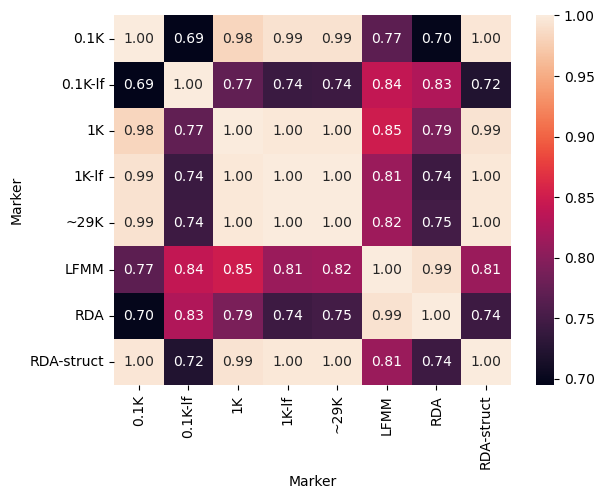

In [10]:
sns.heatmap(data = corr_matrix, annot=True,         # add labels inside cells
    fmt=".2f",)